In [1]:
# ============================================================
# CELL 1: IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.stats import mannwhitneyu, ks_2samp, spearmanr

# Optional packages
# Uncomment if installed
# import powerlaw
# import community as community_louvain   # python-louvain
# import igraph as ig
# import leidenalg

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
# ============================================================
# CELL 2: LOAD DATA
# ============================================================

DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../18-finalize/processed-data/"

nodes_path = f"{DATA_PATH2}20260210-s288c-ANnnotated-Yeast-Interactome.pkl"
edges_path = f"{DATA_PATH1}The_Yeast_Interactome_edges.csv"

nodes = pd.read_pickle(nodes_path)
edges = pd.read_csv(edges_path)

print("Nodes table shape:", nodes.shape)
print("Edges table shape:", edges.shape)
print(edges.columns.tolist()[:15])

Nodes table shape: (3927, 155)
Edges table shape: (31004, 29)
['Binary (literature evidence APID)', 'cor_val_>=4_[σ]', 'cor_val_>=5_[σ]', 'cor_val_[σ]', 'Count of publications', 'experimentral System', 'F_FDR_0.001', 'F_FDR_0.01', 'F_FDR_0.05', 'F_FDR_1e-04', 'Highlight Novel Stylel In Cytoscape (shows score if published)', 'Inter-cluster edge', 'interaction', 'name', 'Pubmed Ids']


In [3]:
# ============================================================
# CELL 3: BUILD FULL INTERACTOME GRAPH
# ============================================================

SOURCE_COL = "source"
TARGET_COL = "target"
NODE_COL = "node"

valid_nodes = set(nodes[NODE_COL])

edges_clean = edges[[SOURCE_COL, TARGET_COL]].dropna().copy()
edges_clean = edges_clean[
    edges_clean[SOURCE_COL].isin(valid_nodes) &
    edges_clean[TARGET_COL].isin(valid_nodes)
]
edges_clean = edges_clean[edges_clean[SOURCE_COL] != edges_clean[TARGET_COL]]

G = nx.from_pandas_edgelist(
    edges_clean,
    source=SOURCE_COL,
    target=TARGET_COL,
    create_using=nx.Graph()
)

node_attr_dict = nodes.set_index(NODE_COL).to_dict(orient="index")
nx.set_node_attributes(G, node_attr_dict)

largest_cc_nodes = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc_nodes).copy()

print("Full graph:")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Connected components:", nx.number_connected_components(G))

print("\nLargest connected component:")
print("Nodes:", G_lcc.number_of_nodes())
print("Edges:", G_lcc.number_of_edges())

Full graph:
Nodes: 3927
Edges: 31004
Connected components: 42

Largest connected component:
Nodes: 3839
Edges: 30955


In [4]:
# ============================================================
# CELL 4: IDENTIFY CHAPERONES
# ============================================================

all_chaperones = set()
for lst in nodes["interacting_chaperones"]:
    if isinstance(lst, (list, set, tuple)):
        all_chaperones.update(lst)

nodes["is_chaperone"] = nodes[NODE_COL].isin(all_chaperones)

chaperone_nodes = set(nodes.loc[nodes["is_chaperone"], NODE_COL])
chaperone_nodes = chaperone_nodes.intersection(G_lcc.nodes())

print("Curated chaperones in node table:", nodes["is_chaperone"].sum())
print("Chaperones in full graph LCC:", len(chaperone_nodes))

Curated chaperones in node table: 66
Chaperones in full graph LCC: 65


In [5]:
# Block A — Do chaperones occupy central positions?
# ============================================================
# CELL 5: CHECK AVAILABLE CENTRALITY COLUMNS
# ============================================================

possible_cols = [c for c in nodes.columns if "central" in c.lower() or "degree" in c.lower()]
possible_cols[:50]

['degree_centrality',
 'betweenness_centrality',
 'eigenvector_centrality',
 'closeness_centrality',
 'load_centrality',
 'information_centrality',
 'Y2H_degree_centrality',
 'Y2H_betweenness_centrality',
 'Y2H_eigenvector_centrality',
 'Y2H_closeness_centrality',
 'Y2H_load_centrality',
 'Y2H_information_centrality']

In [6]:
# ============================================================
# CELL 6: BUILD CENTRALITY ANALYSIS TABLE
# ============================================================

# ---- EDIT THESE COLUMN NAMES IF NEEDED ----
degree_col = "degree_centrality"
betweenness_col = "betweenness_centrality"
closeness_col = "closeness_centrality"
eigenvector_col = "eigenvector_centrality"
load_col = "load_centrality"
information_col = "information_centrality"


centrality_cols = [degree_col, betweenness_col, closeness_col, eigenvector_col, load_col, information_col]

analysis_df = nodes[[NODE_COL, "is_chaperone"] + centrality_cols].copy()

# restrict to nodes in LCC
analysis_df = analysis_df[analysis_df[NODE_COL].isin(G_lcc.nodes())].copy()

print(analysis_df.shape)
analysis_df.head()

(3839, 8)


,node,is_chaperone,degree_centrality,betweenness_centrality,closeness_centrality,eigenvector_centrality,load_centrality,information_centrality
0,YKL063C,False,0.005094,0.002602,0.259652,0.000072,0.002563,0.000570
1,YDL223C,False,0.014519,0.014035,0.302872,0.000536,0.014291,0.000619
2,YPL036W,False,0.029801,0.059166,0.326912,0.004472,0.058826,0.000635
3,YPL050C,False,0.007387,0.000732,0.245821,0.000008,0.000743,0.000590
4,YJR148W,False,0.008151,0.002525,0.277862,0.000093,0.002642,0.000600


In [7]:
# ============================================================
# CELL 7: DESCRIPTIVE COMPARISON OF CENTRALITY
# ============================================================

summary = (
    analysis_df
    .groupby("is_chaperone")[centrality_cols]
    .agg(["mean", "median", "std", "count"])
)

summary

degree_centrality                            \
                          mean    median       std count   
is_chaperone                                               
False                 0.004085  0.001528  0.005573  3774   
True                  0.005404  0.004330  0.005170    65   

             betweenness_centrality                            \
                               mean    median       std count   
is_chaperone                                                    
False                      0.000774  0.000166  0.002376  3774   
True                       0.001741  0.000679  0.002888    65   

             closeness_centrality            ... eigenvector_centrality        \
                             mean    median  ...                    std count   
is_chaperone                                 ...                                
False                    0.237816  0.240719  ...               0.015699  3774   
True                     0.251908  0.256142  ...               0.014678    65   

             load_centrality                           information_centrality  \
                        mean    median       std count                   mean   
is_chaperone                                                                    
False               0.000774  0.000174  0.002359  3774               0.000413   
True                0.001713  0.000595  0.002807    65               0.000487   

                                        
                median       std count  
is_chaperone                            
False         0.000431  0.000163  3774  
True          0.000562  0.000142    65  

[2 rows x 24 columns]

In [8]:
# ============================================================
# CELL 8: NONPARAMETRIC TESTS (CHAPERONES VS NON-CHAPERONES)
# ============================================================

results = []

for col in centrality_cols:
    chap_vals = analysis_df.loc[analysis_df["is_chaperone"], col].dropna()
    non_vals  = analysis_df.loc[~analysis_df["is_chaperone"], col].dropna()

    stat, p = mannwhitneyu(chap_vals, non_vals, alternative="two-sided")
    ks_stat, ks_p = ks_2samp(chap_vals, non_vals)

    results.append({
        "metric": col,
        "chap_mean": chap_vals.mean(),
        "non_mean": non_vals.mean(),
        "chap_median": chap_vals.median(),
        "non_median": non_vals.median(),
        "mannwhitney_u": stat,
        "mannwhitney_p": p,
        "ks_stat": ks_stat,
        "ks_p": ks_p
    })

centrality_test_df = pd.DataFrame(results)
centrality_test_df

,metric,chap_mean,non_mean,chap_median,non_median,mannwhitney_u,mannwhitney_p,ks_stat,ks_p
0,degree_centrality,0.005404,0.004085,0.004330,0.001528,154076.5,0.000374,0.249378,5.478956e-04
1,betweenness_centrality,0.001741,0.000774,0.000679,0.000166,156878.0,0.000102,0.248979,5.627058e-04
2,closeness_centrality,0.251908,0.237816,0.256142,0.240719,159477.5,0.000032,0.358412,7.487058e-08
3,eigenvector_centrality,0.003579,0.003836,0.000078,0.000036,136259.0,0.124689,0.149480,1.035016e-01
4,load_centrality,0.001713,0.000774,0.000595,0.000174,156441.0,0.000125,0.238531,1.103420e-03
5,information_centrality,0.000487,0.000413,0.000562,0.000431,153832.0,0.000434,0.262044,2.322455e-04


In [9]:
# ============================================================
# CELL 9: PERMUTATION TESTS AGAINST RANDOM NODE SETS
# ============================================================

def permutation_test_mean(df, value_col, label_col="is_chaperone", n_perm=10000, seed=42):
    rng = np.random.default_rng(seed)

    observed_group = df.loc[df[label_col], value_col].dropna().values
    background = df[value_col].dropna().values

    n = len(observed_group)
    observed_mean = observed_group.mean()

    perm_means = np.empty(n_perm, dtype=float)
    for i in tqdm(range(n_perm), desc=f"Permuting {value_col}"):
        perm_sample = rng.choice(background, size=n, replace=False)
        perm_means[i] = perm_sample.mean()

    # upper-tail p-value: are chaperones unusually high?
    p_upper = (np.sum(perm_means >= observed_mean) + 1) / (n_perm + 1)

    # lower-tail p-value
    p_lower = (np.sum(perm_means <= observed_mean) + 1) / (n_perm + 1)

    z = (observed_mean - perm_means.mean()) / perm_means.std(ddof=1)

    return {
        "observed_mean": observed_mean,
        "perm_mean": perm_means.mean(),
        "perm_sd": perm_means.std(ddof=1),
        "z_score": z,
        "p_upper": p_upper,
        "p_lower": p_lower,
        "perm_distribution": perm_means
    }

perm_results = {}
for col in centrality_cols:
    perm_results[col] = permutation_test_mean(
        analysis_df,
        value_col=col,
        label_col="is_chaperone",
        n_perm=5000,
        seed=42
    )

perm_summary = pd.DataFrame({
    col: {
        "observed_mean": res["observed_mean"],
        "perm_mean": res["perm_mean"],
        "perm_sd": res["perm_sd"],
        "z_score": res["z_score"],
        "p_upper": res["p_upper"],
        "p_lower": res["p_lower"]
    }
    for col, res in perm_results.items()
}).T

perm_summary

Permuting degree_centrality:   0%|          | 0/5000 [00:00<?, ?it/s]

Permuting betweenness_centrality:   0%|          | 0/5000 [00:00<?, ?it/s]

Permuting closeness_centrality:   0%|          | 0/5000 [00:00<?, ?it/s]

Permuting eigenvector_centrality:   0%|          | 0/5000 [00:00<?, ?it/s]

Permuting load_centrality:   0%|          | 0/5000 [00:00<?, ?it/s]

Permuting information_centrality:   0%|          | 0/5000 [00:00<?, ?it/s]

,observed_mean,perm_mean,perm_sd,z_score,p_upper,p_lower
degree_centrality,0.005404,0.004096,0.000679,1.926719,0.035593,0.964607
betweenness_centrality,0.001741,0.000789,0.000295,3.229190,0.014797,0.985403
closeness_centrality,0.251908,0.238054,0.003485,3.975243,0.000200,1.000000
eigenvector_centrality,0.003579,0.003827,0.001911,-0.129701,0.506699,0.493501
load_centrality,0.001713,0.000789,0.000293,3.157217,0.015797,0.984403
information_centrality,0.000487,0.000414,0.000020,3.649487,0.000200,1.000000


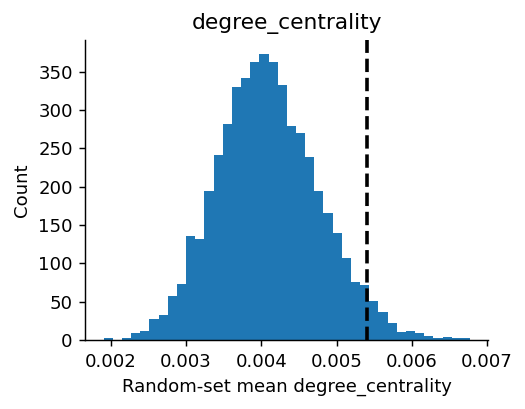

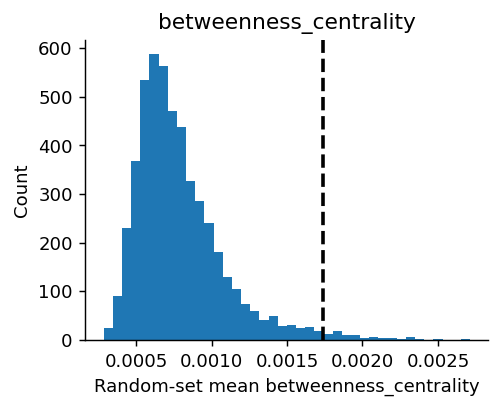

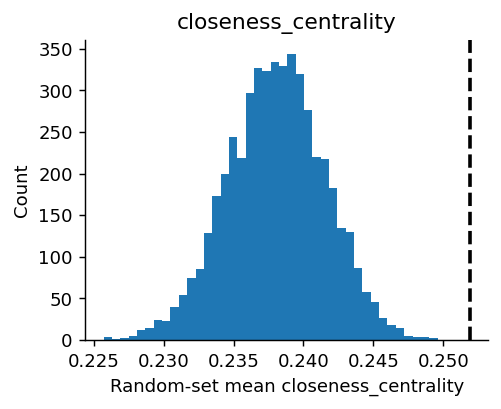

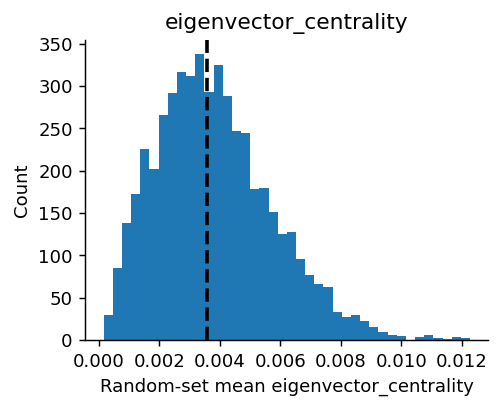

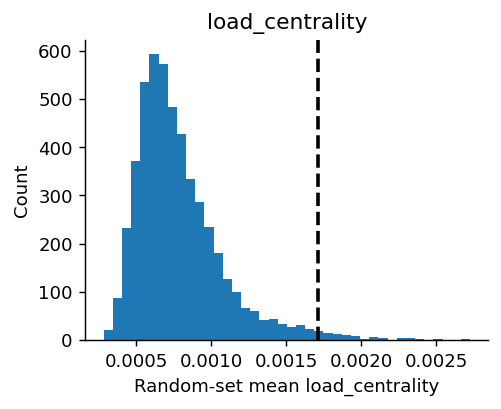

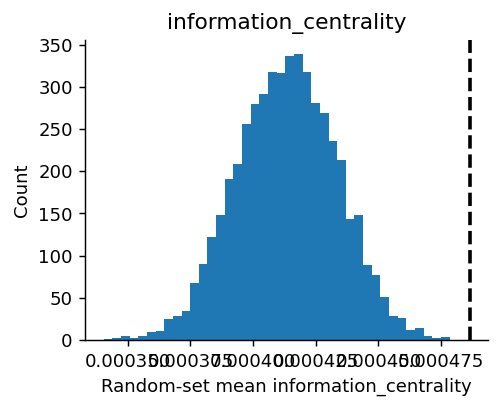

In [10]:
# ============================================================
# CELL 10: PLOT PERMUTATION DISTRIBUTIONS
# ============================================================

for col in centrality_cols:
    res = perm_results[col]

    plt.figure(figsize=(4, 3))
    plt.hist(res["perm_distribution"], bins=40)
    plt.axvline(res["observed_mean"], linestyle="--", linewidth=2, color="black")
    plt.xlabel(f"Random-set mean {col}")
    plt.ylabel("Count")
    plt.title(col)
    plt.show()

/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_74188/4115895072.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([non_vals, chap_vals], labels=["Non-chap", "Chap"])
/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_74188/4115895072.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([non_vals, chap_vals], labels=["Non-chap", "Chap"])
/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_74188/4115895072.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([non_vals, chap_vals], labels=["Non-chap", "Chap"])
/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/

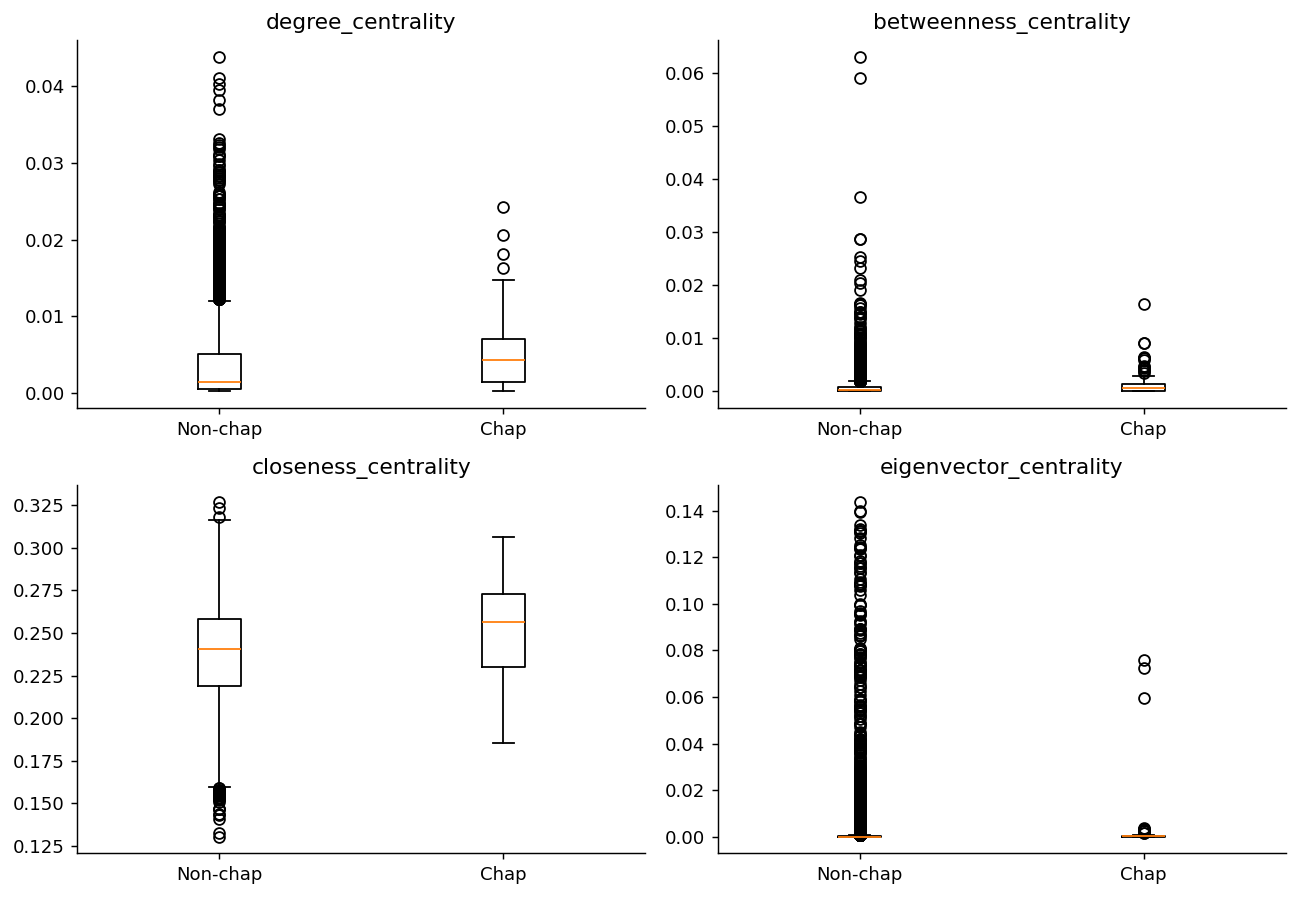

In [11]:
# ============================================================
# CELL 11: BOXPLOTS / VIOLIN PLOTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.ravel()

for ax, col in zip(axes, centrality_cols):
    chap_vals = analysis_df.loc[analysis_df["is_chaperone"], col].dropna()
    non_vals  = analysis_df.loc[~analysis_df["is_chaperone"], col].dropna()

    ax.boxplot([non_vals, chap_vals], labels=["Non-chap", "Chap"])
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [12]:
#Block B — Global topology of the interactome
# ============================================================
# CELL 12: DEGREE DISTRIBUTION
# ============================================================

degree_series = pd.Series(dict(G_lcc.degree()), name="degree")
degree_df = degree_series.rename_axis("node").reset_index()

degree_df["is_chaperone"] = degree_df["node"].isin(chaperone_nodes)

print(degree_df["degree"].describe())
print("\nChaperone degree summary:")
print(degree_df.groupby("is_chaperone")["degree"].describe())

count    3839.000000
mean       16.126595
std        21.863297
min         1.000000
25%         2.000000
50%         7.000000
75%        21.000000
max       172.000000
Name: degree, dtype: float64

Chaperone degree summary:
               count       mean        std  min  25%   50%   75%    max
is_chaperone                                                           
False         3774.0  16.038951  21.881444  1.0  2.0   6.0  20.0  172.0
True            65.0  21.215385  20.295853  1.0  6.0  17.0  28.0   95.0


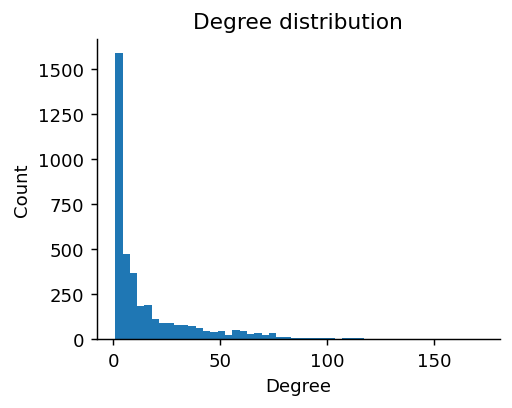

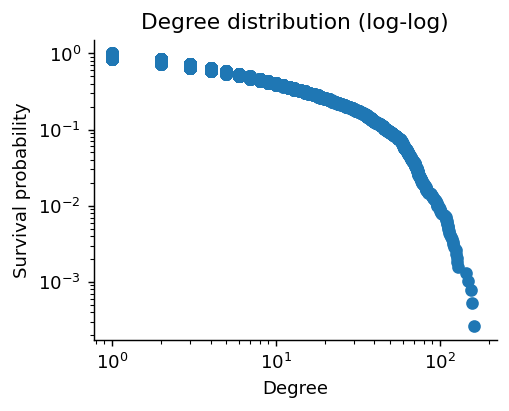

In [13]:
# ============================================================
# CELL 13: DEGREE DISTRIBUTION PLOTS
# ============================================================

# linear scale
plt.figure(figsize=(4, 3))
plt.hist(degree_df["degree"], bins=50)
plt.xlabel("Degree")
plt.ylabel("Count")
plt.title("Degree distribution")
plt.show()

# log-log survival plot
sorted_deg = np.sort(degree_df["degree"].values)
survival = 1.0 - np.arange(1, len(sorted_deg) + 1) / len(sorted_deg)

plt.figure(figsize=(4, 3))
plt.loglog(sorted_deg, survival, marker="o", linestyle="none")
plt.xlabel("Degree")
plt.ylabel("Survival probability")
plt.title("Degree distribution (log-log)")
plt.show()

In [14]:
# ============================================================
# CELL 14: TEST CHAPERONE DEGREE VS BACKGROUND
# ============================================================

chap_deg = degree_df.loc[degree_df["is_chaperone"], "degree"]
all_deg = degree_df["degree"]

u_stat, u_p = mannwhitneyu(chap_deg, degree_df.loc[~degree_df["is_chaperone"], "degree"], alternative="two-sided")
ks_stat, ks_p = ks_2samp(chap_deg, degree_df.loc[~degree_df["is_chaperone"], "degree"])

print("Chaperone mean degree:", chap_deg.mean())
print("Background mean degree:", degree_df.loc[~degree_df["is_chaperone"], "degree"].mean())
print("Mann-Whitney p:", u_p)
print("KS p:", ks_p)

Chaperone mean degree: 21.215384615384615
Background mean degree: 16.038950715421304
Mann-Whitney p: 0.00037423682603867384
KS p: 0.0005478956241352317


In [15]:
# ============================================================
# CELL 15: OPTIONAL POWER-LAW FIT
# ============================================================

# !pip install powerlaw

import powerlaw

degree_values = degree_df["degree"].values
degree_values = degree_values[degree_values > 0]

fit = powerlaw.Fit(degree_values, discrete=True, verbose=False)

print("Estimated alpha:", fit.alpha)
print("Estimated xmin:", fit.xmin)

R, p = fit.distribution_compare("power_law", "lognormal")
print("Power law vs lognormal:")
print("R =", R)
print("p =", p)

fig = fit.plot_pdf(label="Observed")
fit.power_law.plot_pdf(ax=fig, linestyle="--", label="Power law fit")
plt.legend()
plt.xlabel("Degree")
plt.ylabel("PDF")
plt.title("Degree distribution fit")
plt.show()

ModuleNotFoundError: No module named 'powerlaw'

In [16]:
# ============================================================
# CELL 16: DEGREE ASSORTATIVITY
# ============================================================

assortativity = nx.degree_assortativity_coefficient(G_lcc)
print("Degree assortativity coefficient:", assortativity)

Degree assortativity coefficient: 0.3665316428030442


In [17]:
# ============================================================
# CELL 17: RICH-CLUB COEFFICIENT
# ============================================================

# normalized=False is fast and safe to start with
rc = nx.rich_club_coefficient(G_lcc, normalized=False)

rc_df = pd.DataFrame({
    "k": list(rc.keys()),
    "rich_club_coeff": list(rc.values())
}).sort_values("k")

rc_df.head()

,k,rich_club_coeff
0,0,0.004202
1,1,0.005738
2,2,0.007503
3,3,0.009435
4,4,0.011041


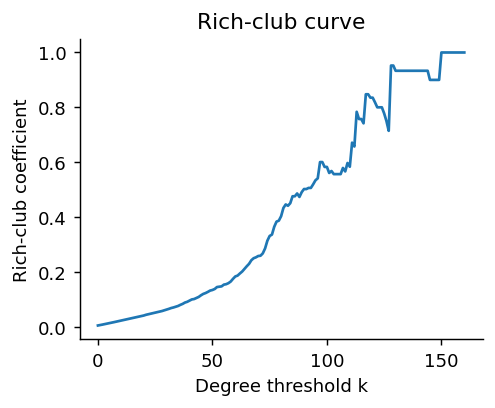

In [18]:
# ============================================================
# CELL 18: PLOT RICH-CLUB CURVE
# ============================================================

plt.figure(figsize=(4, 3))
plt.plot(rc_df["k"], rc_df["rich_club_coeff"])
plt.xlabel("Degree threshold k")
plt.ylabel("Rich-club coefficient")
plt.title("Rich-club curve")
plt.show()

In [19]:
# ============================================================
# CELL 19: CHAPERONES AMONG TOP DEGREE HUBS
# ============================================================

top_percent = 0.10
degree_cut = degree_df["degree"].quantile(1 - top_percent)

degree_df["is_top_hub"] = degree_df["degree"] >= degree_cut

contingency = pd.crosstab(degree_df["is_chaperone"], degree_df["is_top_hub"])
contingency

is_top_hub,False,True
is_chaperone,,
False,3396,378
True,58,7


In [20]:
# ============================================================
# CELL 20: K-CORE DECOMPOSITION
# ============================================================

core_num = nx.core_number(G_lcc)

core_df = pd.DataFrame({
    "node": list(core_num.keys()),
    "core_number": list(core_num.values())
})
core_df["is_chaperone"] = core_df["node"].isin(chaperone_nodes)

print(core_df.groupby("is_chaperone")["core_number"].describe())

               count       mean        std  min  25%   50%   75%   max
is_chaperone                                                          
False         3774.0  10.434552  12.680035  1.0  2.0   5.0  13.0  52.0
True            65.0  10.200000   8.271185  1.0  5.0  11.0  12.0  43.0


In [21]:
# ============================================================
# CELL 21: TEST CHAPERONE CORE POSITION
# ============================================================

chap_core = core_df.loc[core_df["is_chaperone"], "core_number"]
non_core  = core_df.loc[~core_df["is_chaperone"], "core_number"]

u_stat, u_p = mannwhitneyu(chap_core, non_core, alternative="two-sided")
print("Chaperone mean core number:", chap_core.mean())
print("Non-chaperone mean core number:", non_core.mean())
print("Mann-Whitney p:", u_p)

Chaperone mean core number: 10.2
Non-chaperone mean core number: 10.434552199258082
Mann-Whitney p: 0.0047032717816887105


In [22]:
#Block C — More advanced / helpful implementations
# ============================================================
# CELL 22: TRIANGLES PER NODE
# ============================================================

triangles = nx.triangles(G_lcc)

tri_df = pd.DataFrame({
    "node": list(triangles.keys()),
    "triangles": list(triangles.values())
})
tri_df["is_chaperone"] = tri_df["node"].isin(chaperone_nodes)

print(tri_df.groupby("is_chaperone")["triangles"].describe())

u_stat, u_p = mannwhitneyu(
    tri_df.loc[tri_df["is_chaperone"], "triangles"],
    tri_df.loc[~tri_df["is_chaperone"], "triangles"],
    alternative="two-sided"
)

print("Triangle count Mann-Whitney p:", u_p)

               count        mean         std  min  25%   50%    75%     max
is_chaperone                                                               
False         3774.0  194.200848  484.126688  0.0  0.0   6.0   90.0  3998.0
True            65.0  120.430769  216.242844  0.0  6.0  69.0  139.0  1158.0
Triangle count Mann-Whitney p: 0.0008806455614976344


In [23]:
# ============================================================
# CELL 23: APPROXIMATE SQUARE / 4-CYCLE COUNTS
# ============================================================

def count_squares_node(G, node):
    """
    Approximate number of 4-cycles touching a node.
    Can be slow for very high-degree nodes.
    """
    nbrs = list(G.neighbors(node))
    count = 0
    for i in range(len(nbrs)):
        for j in range(i + 1, len(nbrs)):
            u, v = nbrs[i], nbrs[j]
            common = set(G.neighbors(u)).intersection(G.neighbors(v))
            common.discard(node)
            count += len(common)
    return count // 2

sample_nodes = list(chaperone_nodes)[:10]  # start small
square_counts = {n: count_squares_node(G_lcc, n) for n in tqdm(sample_nodes)}

square_counts

  0%|          | 0/10 [00:00<?, ?it/s]

{'YKL117W': 3,
 'YNL077W': 0,
 'YDR168W': 0,
 'YGR285C': 43106,
 'YOR254C': 3326,
 'YLR259C': 2886,
 'YER048C': 181,
 'YIL016W': 1035,
 'YER103W': 1146,
 'YDR258C': 45}

In [24]:
# ============================================================
# CELL 24: GREEDY MODULARITY COMMUNITIES
# ============================================================

greedy_comms = list(nx.algorithms.community.greedy_modularity_communities(G_lcc))
greedy_mod = nx.algorithms.community.modularity(G_lcc, greedy_comms)

print("Greedy modularity:", greedy_mod)
print("Number of communities:", len(greedy_comms))

# map node -> community
greedy_map = {}
for i, comm in enumerate(greedy_comms):
    for node in comm:
        greedy_map[node] = i

community_df = pd.DataFrame({
    "node": list(greedy_map.keys()),
    "greedy_comm": list(greedy_map.values())
})
community_df["is_chaperone"] = community_df["node"].isin(chaperone_nodes)

community_df.head()

Greedy modularity: 0.7083756301221537
Number of communities: 30


,node,greedy_comm,is_chaperone
0,YER057C,0,False
1,YGL065C,0,False
2,YKL008C,0,False
3,YCL028W,0,False
4,YDR264C,0,False


In [25]:
# ============================================================
# CELL 25: CHAPERONE COMMUNITY SPREAD
# ============================================================

chap_comm_counts = (
    community_df.loc[community_df["is_chaperone"], "greedy_comm"]
    .value_counts()
    .sort_index()
)

chap_comm_counts

greedy_comm
0    43
1     2
2     5
3     1
4     8
7     6
Name: count, dtype: int64

In [26]:
# ============================================================
# CELL 26: OPTIONAL LOUVAIN COMMUNITY DETECTION
# ============================================================

# !pip install python-louvain

import community as community_louvain

louvain_partition = community_louvain.best_partition(G_lcc, random_state=42)

louvain_df = pd.DataFrame({
    "node": list(louvain_partition.keys()),
    "louvain_comm": list(louvain_partition.values())
})
louvain_df["is_chaperone"] = louvain_df["node"].isin(chaperone_nodes)

n_louvain = louvain_df["louvain_comm"].nunique()
print("Number of Louvain communities:", n_louvain)

# modularity
louvain_groups = {}
for node, comm in louvain_partition.items():
    louvain_groups.setdefault(comm, set()).add(node)

louvain_mod = nx.algorithms.community.modularity(G_lcc, list(louvain_groups.values()))
print("Louvain modularity:", louvain_mod)

ModuleNotFoundError: No module named 'community'

In [27]:
# ============================================================
# CELL 27: BUILD WEIGHTED GRAPH
# ============================================================

# ---- PICK ONE EDGE SCORE COLUMN ----
# Examples: "score_FDR", "score_cor", "score_FDR+cor"
weight_col = "score_FDR+cor"

weighted_edges = edges[[SOURCE_COL, TARGET_COL, weight_col]].dropna().copy()
weighted_edges = weighted_edges[
    weighted_edges[SOURCE_COL].isin(valid_nodes) &
    weighted_edges[TARGET_COL].isin(valid_nodes)
]
weighted_edges = weighted_edges[weighted_edges[SOURCE_COL] != weighted_edges[TARGET_COL]]

G_weighted = nx.from_pandas_edgelist(
    weighted_edges,
    source=SOURCE_COL,
    target=TARGET_COL,
    edge_attr=weight_col,
    create_using=nx.Graph()
)

largest_cc_w = max(nx.connected_components(G_weighted), key=len)
G_weighted_lcc = G_weighted.subgraph(largest_cc_w).copy()

print("Weighted graph LCC:")
print("Nodes:", G_weighted_lcc.number_of_nodes())
print("Edges:", G_weighted_lcc.number_of_edges())

Weighted graph LCC:
Nodes: 3839
Edges: 30955


In [28]:
# ============================================================
# CELL 28: WEIGHTED CLUSTERING
# ============================================================

w_clust = nx.average_clustering(G_weighted_lcc, weight=weight_col)
print("Weighted average clustering:", w_clust)

Weighted average clustering: 0.17730072068071384


In [29]:
# ============================================================
# CELL 29: NODE STRENGTH (WEIGHTED DEGREE)
# ============================================================

strength_dict = dict(G_weighted_lcc.degree(weight=weight_col))

strength_df = pd.DataFrame({
    "node": list(strength_dict.keys()),
    "strength": list(strength_dict.values())
})
strength_df["is_chaperone"] = strength_df["node"].isin(chaperone_nodes)

print(strength_df.groupby("is_chaperone")["strength"].describe())

u_stat, u_p = mannwhitneyu(
    strength_df.loc[strength_df["is_chaperone"], "strength"],
    strength_df.loc[~strength_df["is_chaperone"], "strength"],
    alternative="two-sided"
)
print("Weighted degree / strength p-value:", u_p)

               count       mean         std  min   25%   50%   75%    max
is_chaperone                                                             
False         3774.0  65.899311  100.395528  2.0   8.0  24.0  74.0  740.0
True            65.0  75.415385   72.687665  2.0  26.0  50.0  96.0  324.0
Weighted degree / strength p-value: 0.00030571398062009965


In [30]:
# ============================================================
# CELL 30: LOOK FOR CONTEXT / COMPARTMENT COLUMNS
# ============================================================

[c for c in nodes.columns if "compart" in c.lower() or "local" in c.lower() or "condition" in c.lower()][:50]

['localization_keywords']

In [ ]:
# ============================================================
# CELL 31: EXAMPLE CONTEXT-SPECIFIC NETWORK
# ============================================================

# Example only -- replace with your real column and value
# context_col = "cell_compartment"
# context_value = "cytoplasm"

# context_nodes = set(nodes.loc[nodes[context_col] == context_value, NODE_COL]).intersection(G.nodes())
# G_context = G.subgraph(context_nodes).copy()

# if G_context.number_of_nodes() > 0:
#     largest_context_cc = max(nx.connected_components(G_context), key=len)
#     G_context_lcc = G_context.subgraph(largest_context_cc).copy()
#     print("Context LCC nodes:", G_context_lcc.number_of_nodes())
#     print("Context assortativity:", nx.degree_assortativity_coefficient(G_context_lcc))